# **Detecção e diagnóstico de anomalias em vibração de rolamentos (CWRU)**

ECM514 — Ciência de Dados · Projeto Desafio do 2º semestre.

O notebook segue o roteiro das aulas — *Clean Data*, *Pre-Processing*, *Select
Models*, *GridSearch*, *Melhor modelo*, *Predição* — com as etapas próprias do
problema (validação física e detecção one-class). A lógica mora em `src/`; aqui
só orquestramos. Justificativas completas no relatório (`docs/relatorio/`).

## 0. Ambiente

In [1]:
import os, sys, subprocess

REPO = "https://github.com/Nyfeu/Vibration_Analysis.git"
if "google.colab" in sys.modules:
    if not os.path.isdir("Vibration_Analysis"):
        subprocess.run(["git", "clone", "--depth", "1", REPO], check=True)
    os.chdir("Vibration_Analysis")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

from src.data import SEED, FS_HZ, fixar_seeds
rng = fixar_seeds(SEED)
pd.set_option("display.width", 160)
print("diretório:", os.getcwd(), "| SEED =", SEED)

diretório: /home/nyfeu/Projects/Vibration_Analysis | SEED = 42


# **Clean Data**

Os 56 arquivos `.mat` do CWRU estão versionados em `data/raw/`, com o SHA-256 de
cada um no manifesto. Nenhuma gravação é excluída por qualidade; as que não
mostram o defeito ficam **com ressalva** (auditoria de Smith & Randall, 2015,
em `docs/arquivos_excluidos.md`). Três problemas de dados são tratados na leitura:

1. os normais (97–100) estão a **48 kHz**, não 12 kHz → decimação por 4;
2. `99.mat` contém também as variáveis de `98.mat` → leitura pelo nome gravado no manifesto;
3. `98.mat` e `99.mat` não têm a rotação medida → rotação nominal.

In [2]:
from src.data import ler_manifesto, catalogo

manifesto = ler_manifesto()
print("arquivos no manifesto:", len(manifesto))
display(manifesto.groupby(["classe", "fs_hz"]).size().rename("arquivos").to_frame())
principal = catalogo("principal")
print("conjunto principal:", len(principal), "gravações | generalização (OR @3/@12):", len(catalogo("generalizacao")))

arquivos no manifesto: 56


,,arquivos
classe,fs_hz,
B,12000,12
IR,12000,12
OR,12000,28
normal,48000,4


conjunto principal: 40 gravações | generalização (OR @3/@12): 16


1. **Quais dados foram identificados como problemáticos e quantos registros foram excluídos?**

In [3]:
from src.evaluation import ler_auditoria

aud = ler_auditoria().merge(manifesto[["id", "classe"]], left_on="registro", right_on="id")
aud = aud[aud["registro"].isin(principal["id"])]
display(pd.crosstab(aud["classe"], aud["grupo"]).rename(columns={"Y": "Y (diagnosticável)", "P": "P (parcial)", "N": "N (não)"}))
print("Excluídos: 0. Mantidos com ressalva: os grupos P e N (Smith & Randall, 2015, Tab. B2) e os normais a 48 kHz.")

grupo,N (não),P (parcial),Y (diagnosticável)
classe,,,
B,5,4,3
IR,0,0,12
OR,1,2,9


Excluídos: 0. Mantidos com ressalva: os grupos P e N (Smith & Randall, 2015, Tab. B2) e os normais a 48 kHz.


### Decimação e banda comum

Depois da decimação, **todas** as gravações passam pelo mesmo passa-baixas de
4,8 kHz. Sem isso, a faixa 4,8–6 kHz (com resíduo de *aliasing* nos normais)
diferenciaria normal de falha por artefato.

fracao_antes          fracao_depois         
                min      max           min      max
classe                                             
normal      0.00132  0.00934       0.00025  0.00051
IR          0.00058  0.00328       0.00005  0.00083
B           0.00045  0.02217       0.00002  0.00044
OR          0.00102  0.05465       0.00004  0.00019

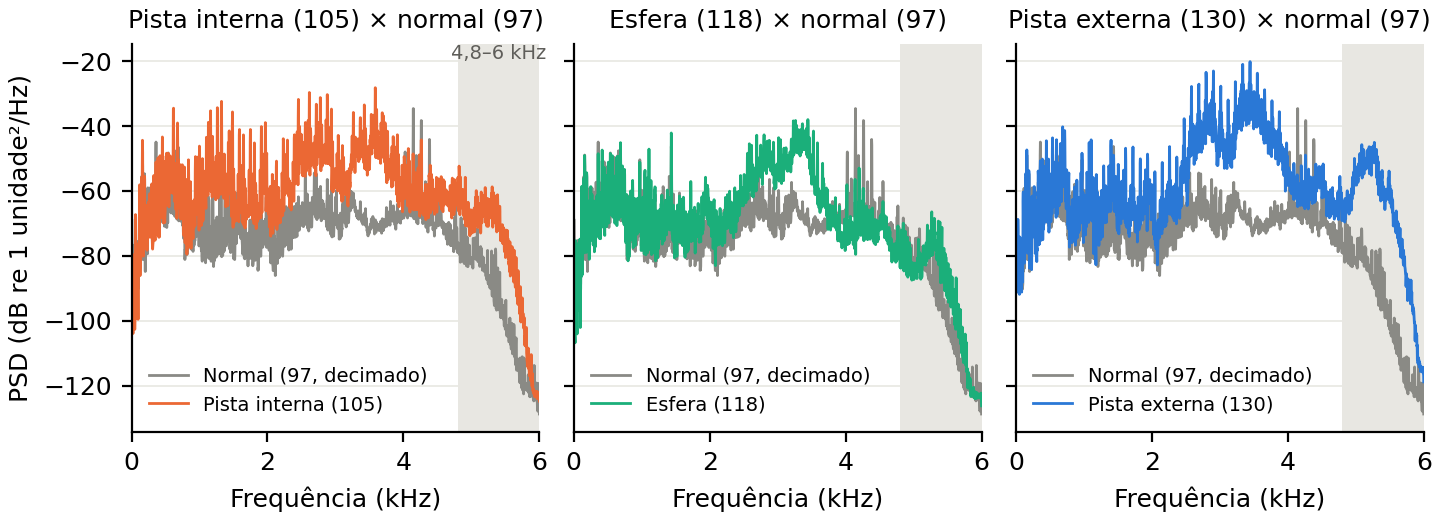

In [4]:
subprocess.run([sys.executable, "-m", "scripts.gerar_artefatos_dados"], check=True)
display(pd.read_csv("results/metrics/energia_banda_4k8_6k_por_classe.csv", header=[0, 1], index_col=0).round(5))
display(Image("results/figures/espectro_normal_decimado_vs_falhas.png", width=800))

# **Pre-Processing**

## Train, Test split

O split **não** é aleatório: janelas da mesma gravação são quase idênticas, e
espalhá-las entre treino e teste mede memorização da gravação. Treino com 0, 1 e
2 HP; teste com 3 HP. Cada gravação tem uma única carga, então nenhuma gravação
fica nos dois lados (verificado em `split_por_carga`).

A janela tem 4096 amostras (0,341 s): 3 períodos da gaiola (FTF) na menor
rotação do conjunto, arredondado para potência de 2.

In [5]:
from src.data import montar_janelas, split_por_carga, contagem_janelas, tamanho_janela

print("tamanho da janela:", tamanho_janela(manifesto["rpm"].min()), "amostras")
X, meta = montar_janelas("principal")
Xg, meta_g = montar_janelas("generalizacao")
treino, teste = split_por_carga(meta)
display(contagem_janelas(meta))

tamanho da janela: 4096 amostras


carga_hp,0,1,2,3,total
classe,,,,,
normal,28,58,58,58,202
IR,174,174,174,175,697
B,174,174,174,174,696
OR,174,174,174,174,696
total,550,580,580,581,2291


2. **Informe a quantidade de instâncias (janelas) de Treinamento e Teste.**

In [6]:
print(f"Treinamento: {treino.sum()} janelas ({meta[treino].registro.nunique()} gravações, 0/1/2 HP)")
print(f"Teste: {teste.sum()} janelas ({meta[teste].registro.nunique()} gravações, 3 HP)")
print(f"Generalização (OR @3/@12, todas as cargas): {len(meta_g)} janelas")

Treinamento: 1710 janelas (30 gravações, 0/1/2 HP)
Teste: 581 janelas (10 gravações, 3 HP)
Generalização (OR @3/@12, todas as cargas): 928 janelas


## Features

Por janela: 5 do domínio do tempo (RMS, curtose de Pearson, fator de crista,
assimetria, pico) e 3 escores do **espectro de envelope** (BPFO, BPFI, BSF, em dB
acima do fundo local, nas frequências calculadas pela geometria do 6205 e pela
rotação de cada gravação). Quatro conjuntos formam uma ablação; "forma" retira
RMS e pico, que dependem só da amplitude.

In [7]:
from src.features import matriz_features, CONJUNTOS_FEATURES

F = matriz_features(X, meta["rpm"].to_numpy(), FS_HZ)
Fg = matriz_features(Xg, meta_g["rpm"].to_numpy(), FS_HZ)
for nome, cols in CONJUNTOS_FEATURES.items():
    print(f"{nome:15s} {cols}")
F.groupby(meta["classe"].to_numpy()).median().round(2)

tempo           ['rms', 'curtose', 'fator_crista', 'assimetria', 'pico']
envelope        ['env_bpfo', 'env_bpfi', 'env_bsf']
tempo+envelope  ['rms', 'curtose', 'fator_crista', 'assimetria', 'pico', 'env_bpfo', 'env_bpfi', 'env_bsf']
forma           ['curtose', 'fator_crista', 'assimetria', 'env_bpfo', 'env_bpfi', 'env_bsf']


,rms,curtose,fator_crista,assimetria,pico,env_bpfo,env_bpfi,env_bsf
B,0.13,3.33,4.15,0.01,0.54,1.46,2.67,1.09
IR,0.29,7.74,6.11,0.14,1.66,-0.44,9.19,0.85
OR,0.56,7.81,5.15,0.03,2.97,6.38,3.74,2.00
normal,0.06,2.96,3.71,0.03,0.21,1.42,1.51,2.19


## Scaler

O `StandardScaler` vai **dentro do `Pipeline`** de cada modelo: em cada fold da
validação cruzada e no ajuste final ele é ajustado só nos dados de treino.

# **Validação física**

Antes de qualquer modelo: o pico do espectro de envelope cai na frequência de
defeito prevista pela teoria? Uma gravação de falha é *confirmada* quando a
família dominante é a da classe declarada e supera o maior escore das normais.

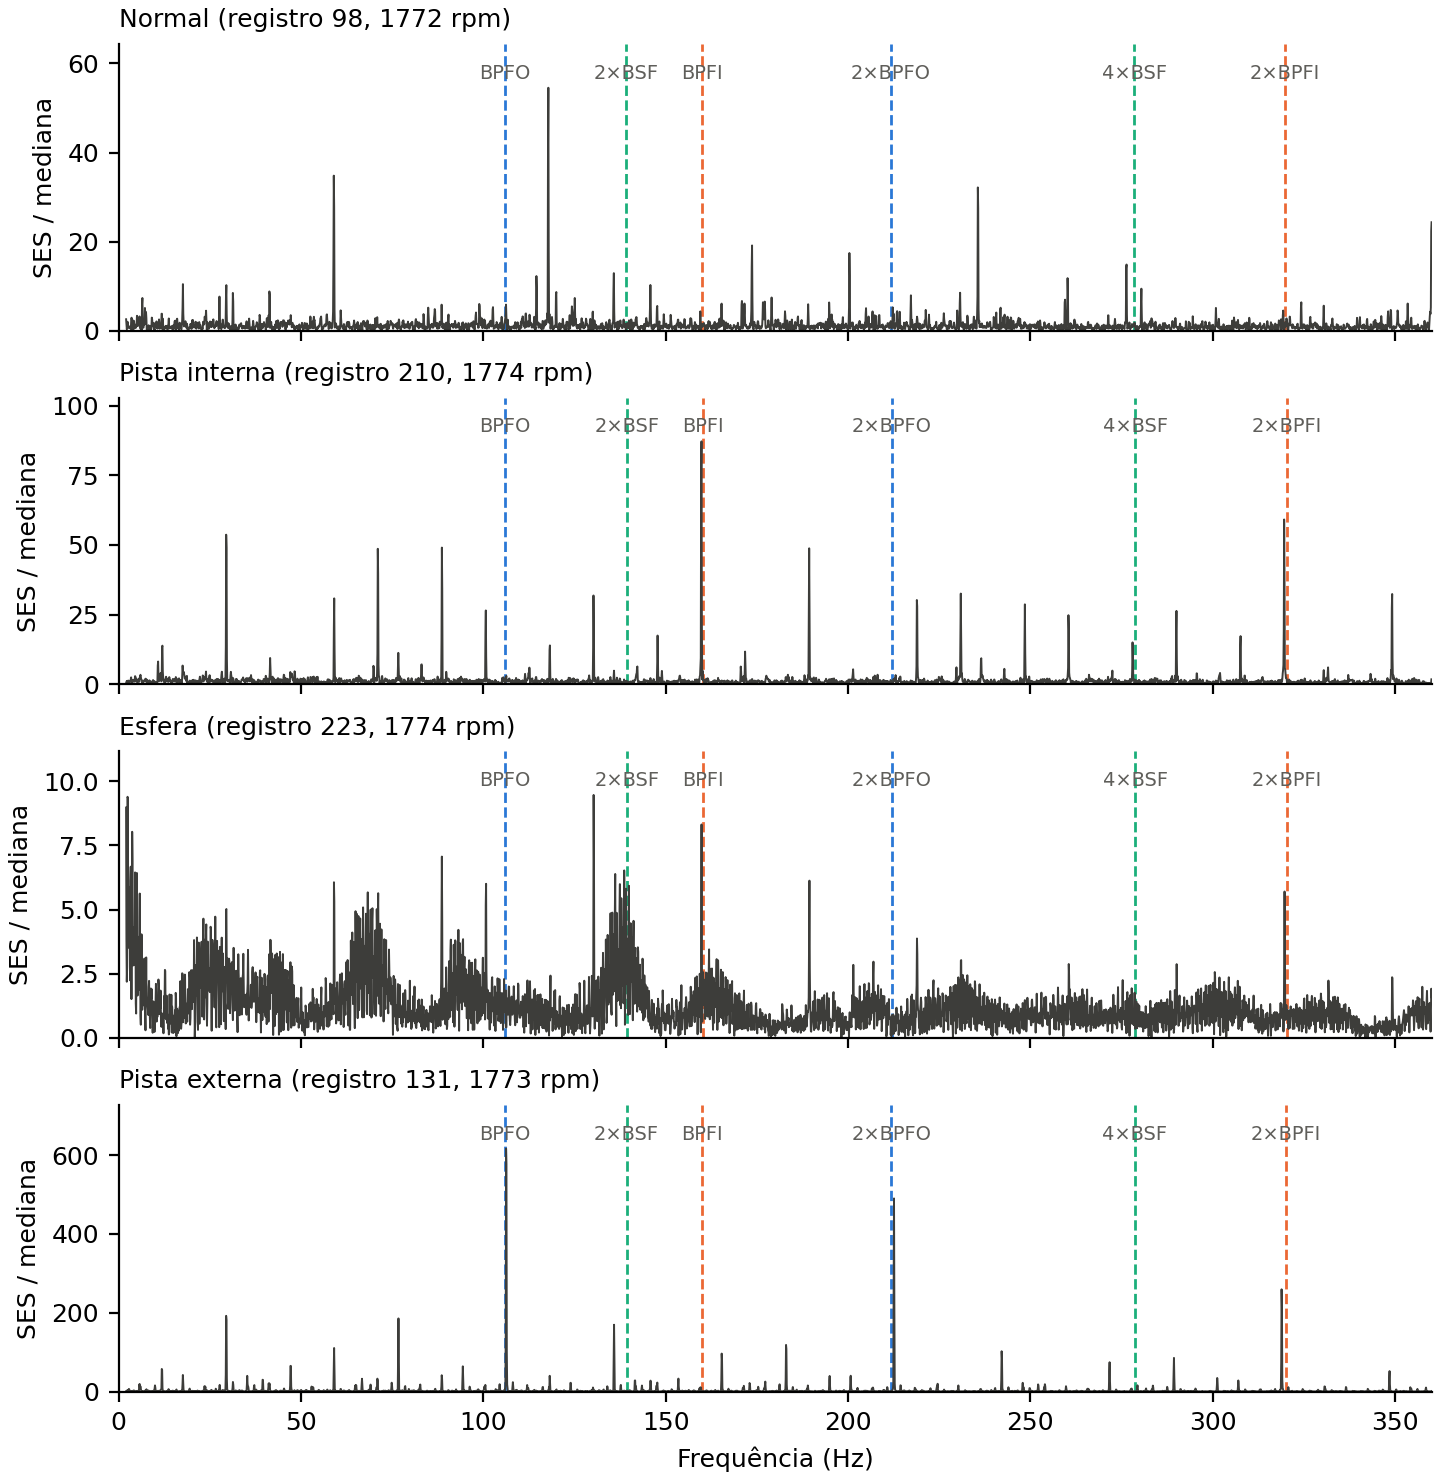

Gravações de falha confirmadas — nosso critério × Smith & Randall (Y por método):


,gravacoes,bruto,prebranqueado,kurtograma,smith_m1,smith_m2,smith_m3
grupo_classe,,,,,,,
IR,12,12,12,12,11,12,12
B,12,0,5,0,1,2,2
OR @6,12,8,8,10,8,8,9
OR @3,8,8,8,8,8,8,8
OR @12,8,8,8,8,8,8,8


In [8]:
from src.evaluation import comparar_preprocessamentos

subprocess.run([sys.executable, "-m", "scripts.gerar_artefatos_envelope"], check=True)
display(Image("results/figures/envelope_por_classe_1hp.png", width=800))
print("Gravações de falha confirmadas — nosso critério × Smith & Randall (Y por método):")
comparar_preprocessamentos()

# **Detecção one-class**

Treinada **somente com normais** de 0/1/2 HP (`treinar_detector` recusa
qualquer janela de falha). Cada detector é um `Pipeline(StandardScaler, modelo)`;
o limiar de alarme é o percentil 99 dos escores normais de treino.

In [9]:
from src.experimentos import rodar_deteccao, tpr_por_grupo_smith

met_det, por_reg_det, erros_det, _ = rodar_deteccao(F, meta, Fg, meta_g)
met_det[["features", "detector", "auc", "tpr", "fpr", "tpr_generalizacao"]].round(3)

,features,detector,auc,tpr,fpr,tpr_generalizacao
0,tempo,mahalanobis,1.000,1.000,0.034,1.000
1,tempo,isolation_forest,0.995,0.776,0.000,1.000
2,tempo,ocsvm,1.000,1.000,0.293,1.000
3,tempo,autoencoder,1.000,1.000,0.000,1.000
4,envelope,mahalanobis,0.718,0.576,0.138,0.762
5,envelope,isolation_forest,0.688,0.434,0.086,0.455
6,envelope,ocsvm,0.771,0.759,0.500,0.856
7,envelope,autoencoder,0.828,0.545,0.034,0.689
8,tempo+envelope,mahalanobis,1.000,1.000,0.121,1.000
9,tempo+envelope,isolation_forest,0.985,0.902,0.069,1.000


AUC = 1,00 com features de tempo é **suspeito** (CLAUDE.md §7). Não é vazamento
(split por gravação verificado), mas o RMS sozinho separa normal de falha —
inclusive nas gravações sem assinatura física (grupo N):

In [10]:
from sklearn.metrics import roc_auc_score

y_te = (meta.loc[teste, "classe"] != "normal").to_numpy()
print("AUC só com RMS:", roc_auc_score(y_te, F.loc[teste, "rms"]).round(3))
display(tpr_por_grupo_smith(por_reg_det).round(2))

AUC só com RMS: 1.0


grupo                               Y     P     N
features       detector                          
envelope       autoencoder       0.67  0.02  0.42
               isolation_forest  0.55  0.00  0.29
               mahalanobis       0.73  0.00  0.41
               ocsvm             0.91  0.14  0.61
forma          autoencoder       0.85  1.00  0.59
               isolation_forest  0.84  0.95  0.44
               mahalanobis       0.85  1.00  0.67
               ocsvm             0.91  1.00  0.86
tempo          autoencoder       1.00  1.00  1.00
               isolation_forest  0.84  1.00  0.47
               mahalanobis       1.00  1.00  1.00
               ocsvm             1.00  1.00  1.00
tempo+envelope autoencoder       1.00  1.00  1.00
               isolation_forest  0.93  1.00  0.78
               mahalanobis       1.00  1.00  1.00
               ocsvm             1.00  1.00  1.00

# **Select Models**

Validação cruzada **no treino**, com `LeaveOneGroupOut` e grupo = carga (cada
fold deixa uma carga de fora — a mesma lógica do teste). Para comparação, a
mesma conta com `StratifiedKFold` embaralhado, que espalha janelas da mesma
gravação entre treino e validação.

3. **Informe para cada modelo a acurácia obtida no treinamento (validação cruzada).**

In [11]:
from src.classification import selecionar_modelos

cols = CONJUNTOS_FEATURES["tempo+envelope"]
x_tr, y_tr, g_tr = F.loc[treino, cols], meta.loc[treino, "classe"], meta.loc[treino, "carga_hp"]
selecao = selecionar_modelos(x_tr, y_tr, g_tr)
display(selecao.round(3))
print("Melhor preditor (CV por carga):", selecao.loc[0, "modelo"])

,modelo,cv_por_carga,cv_por_carga_desvio,cv_embaralhado
0,Random Forest,0.979,0.010,0.994
1,SVM (RBF),0.924,0.011,0.952
2,KNN (k=3),0.923,0.017,0.944
3,KNN (k=9),0.920,0.015,0.936
4,Regressão Logística,0.862,0.021,0.881


Melhor preditor (CV por carga): Random Forest


# **GridSearch**

Hiperparâmetros do Random Forest e do SVM por `GridSearchCV` sobre o pipeline,
com a mesma validação por carga.

In [12]:
from src.classification import ajustar_hiperparametros, GRADES

buscas = {nome: ajustar_hiperparametros(nome, x_tr, y_tr, g_tr) for nome in GRADES}
for nome, b in buscas.items():
    print(f"{nome}: melhor CV = {b.best_score_:.3f} | {b.best_params_}")

Random Forest: melhor CV = 0.984 | {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
SVM (RBF): melhor CV = 0.980 | {'clf__C': 10, 'clf__gamma': 0.1}


# **Melhor modelo**

4. **Analise o modelo final no teste (3 HP). Ele é um bom modelo? Discuta com base em métricas.**

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from src.data import ORDEM_CLASSES

model = buscas["Random Forest"].best_estimator_
y_te_cls = meta.loc[teste, "classe"]
y_pred = model.predict(F.loc[teste, cols])
print(f"Acurácia no teste: {accuracy_score(y_te_cls, y_pred):.4f}\n")
print(classification_report(y_te_cls, y_pred, labels=ORDEM_CLASSES))
pd.DataFrame(confusion_matrix(y_te_cls, y_pred, labels=ORDEM_CLASSES),
             index=[f"verdadeira {c}" for c in ORDEM_CLASSES],
             columns=[f"predita {c}" for c in ORDEM_CLASSES])

Acurácia no teste: 0.9570

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        58
          IR       1.00      0.98      0.99       175
           B       0.88      0.99      0.93       174
          OR       0.99      0.89      0.94       174

    accuracy                           0.96       581
   macro avg       0.97      0.96      0.96       581
weighted avg       0.96      0.96      0.96       581



,predita normal,predita IR,predita B,predita OR
verdadeira normal,58,0,0,0
verdadeira IR,0,171,4,0
verdadeira B,0,0,173,1
verdadeira OR,0,0,20,154


In [14]:
imp = pd.Series(model.named_steps["clf"].feature_importances_, index=cols).sort_values(ascending=False)
print("Importância das features (Random Forest):")
print(imp.round(3).to_string())
print(f"\nRMS + pico = {imp[['rms', 'pico']].sum():.1%} da importância; escore de BSF = {imp['env_bsf']:.1%}")

Importância das features (Random Forest):
rms             0.298
pico            0.265
env_bpfo        0.131
curtose         0.101
env_bpfi        0.093
fator_crista    0.047
env_bsf         0.033
assimetria      0.032

RMS + pico = 56.3% da importância; escore de BSF = 3.3%


**Discussão.** A acurácia é alta (~96%), mas não é evidência de diagnóstico:

- a classe **esfera** é acertada em ~99% das janelas, embora a validação física
  não tenha confirmado o defeito em **nenhuma** gravação de esfera pelo envelope
  bruto, e a gravação 225 (sem assinatura) seja acertada em 100%;
- RMS e pico somam mais da metade da importância: o modelo reconhece o **nível
  de vibração de cada montagem**, que no CWRU se repete nas quatro cargas.

A seção *Predição* testa isso em montagens que o modelo nunca viu.

## Ablação de features e CNN 1D

Os mesmos passos (seleção + GridSearch + teste) para cada conjunto de features,
e uma CNN 1D sobre o sinal bruto como contraponto (exige PyTorch, instalado no Colab).

In [15]:
subprocess.run([sys.executable, "-m", "scripts.gerar_artefatos_classificacao"], check=True)
pd.read_csv("results/metrics/classificacao_metricas.csv").round(3)

,features,classificador,cv_por_carga,acuracia,acc_normal,acc_IR,acc_B,acc_OR,generalizacao_OR
0,tempo,Random Forest,0.972,0.933,1.000,0.909,0.971,0.897,0.500
1,tempo,SVM (RBF),0.974,0.928,1.000,0.897,0.966,0.897,0.500
2,envelope,Random Forest,0.753,0.676,0.000,0.937,0.649,0.667,0.760
3,envelope,SVM (RBF),0.713,0.671,0.052,0.966,0.603,0.649,0.677
4,tempo+envelope,Random Forest,0.984,0.957,1.000,0.977,0.994,0.885,0.400
5,tempo+envelope,SVM (RBF),0.980,0.950,1.000,0.994,0.966,0.874,0.115
6,forma,Random Forest,0.860,0.654,0.069,0.720,0.667,0.770,0.581
7,forma,SVM (RBF),0.865,0.756,0.241,0.977,0.730,0.730,0.295
8,sinal bruto,CNN 1D,NaN,0.971,1.000,0.903,1.000,1.000,0.356
9,sinal normalizado,CNN 1D,NaN,0.997,1.000,0.989,1.000,1.000,0.641


# **Predição**

5. **Aplique o modelo final a casos novos.** Os "casos novos" são as gravações
de pista externa com o defeito a 3 h e a 12 h — posições que o modelo nunca viu.
A resposta correta é sempre "OR".

In [16]:
pred_g = model.predict(Fg[cols])
print(f"Classificadas como OR: {(pred_g == 'OR').mean():.1%}")
pd.crosstab([meta_g["posicao_or_h"].rename("posição"), meta_g["diametro_pol"].rename("diâmetro")],
            pd.Series(pred_g, name="predita"))

Classificadas como OR: 40.0%


predita             B   IR   OR
posição diâmetro               
12      0.007       2  228    2
        0.021     109    0  123
3       0.007       0    0  232
        0.021      11  207   14

In [17]:
cols_env = CONJUNTOS_FEATURES["envelope"]
modelo_env = ajustar_hiperparametros("Random Forest", F.loc[treino, cols_env], y_tr, g_tr).best_estimator_
print(f"Só envelope — teste: {accuracy_score(y_te_cls, modelo_env.predict(F.loc[teste, cols_env])):.1%} | "
      f"generalização (OR): {(modelo_env.predict(Fg[cols_env]) == 'OR').mean():.1%}")

Só envelope — teste: 67.6% | generalização (OR): 76.0%


O modelo só com envelope acerta menos no teste, mas **generaliza melhor** para o
defeito em outra posição: ele usa a frequência do defeito, não a amplitude da montagem.

# **Generalização entre montagens**

No CWRU, cada combinação de defeito e diâmetro foi ensaiada numa única montagem,
presente nas quatro cargas — o split por carga não testa montagens novas. Aqui o
tipo de falha (IR, B, OR) é avaliado com `LeaveOneGroupOut` por **diâmetro**
(acaso = 33%), e comparado a uma **regra física sem treino**: a classe da família
de envelope dominante.

In [18]:
from src.experimentos import classificacao_por_montagem, prever_regra_fisica

met_mont, _ = classificacao_por_montagem(F, meta)
met_mont.round(3)

,features,modelo,acuracia,acc_IR,acc_B,acc_OR
0,tempo,Random Forest,0.420,0.004,0.922,0.333
1,tempo,SVM (RBF),0.356,0.274,0.767,0.027
2,tempo,KNN (k=9),0.427,0.258,0.705,0.318
3,envelope,Random Forest,0.456,0.651,0.435,0.280
4,envelope,SVM (RBF),0.353,0.631,0.428,0.000
5,envelope,KNN (k=9),0.479,0.659,0.431,0.348
6,tempo+envelope,Random Forest,0.457,0.248,0.872,0.250
7,tempo+envelope,SVM (RBF),0.411,0.471,0.369,0.394
8,tempo+envelope,KNN (k=9),0.538,0.631,0.359,0.624
9,forma,Random Forest,0.258,0.422,0.349,0.003


Com a montagem nova, todos os modelos treinados caem para perto do acaso, e a
regra física — que não aprende nada dos dados — é a melhor. Na generalização
(OR @3/@12), ela acerta:

In [19]:
print(f"Regra física na generalização: {(prever_regra_fisica(Fg) == 'OR').mean():.1%} classificadas como OR")

Regra física na generalização: 99.8% classificadas como OR


# **Artefatos e testes**

In [20]:
subprocess.run([sys.executable, "-m", "scripts.gerar_artefatos_deteccao"], check=True)
subprocess.run([sys.executable, "-m", "pytest", "-q", "tests"], check=True)

...

.

.

.......

...........

...........

...

..................                  [100%]
=============================== warnings summary ===============================
tests/test_classificacao.py: 33 warnings
  /usr/lib/python3/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=199866) is multi-threaded, use of fork() may lead to deadlocks in the child.
    pid = os.fork()

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
55 passed, 33 warnings in 34.83s


CompletedProcess(args=['/home/nyfeu/Projects/Vibration_Analysis/.venv/bin/python', '-m', 'pytest', '-q', 'tests'], returncode=0)